<a href="https://colab.research.google.com/github/Gungun518/AI-ML/blob/main/Worksheet5_CNN_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 — Worksheet 5: CNN Image Classification
### Amazon Fruit Classification using TensorFlow & Keras

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Task 1: Data Understanding and Visualization

Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


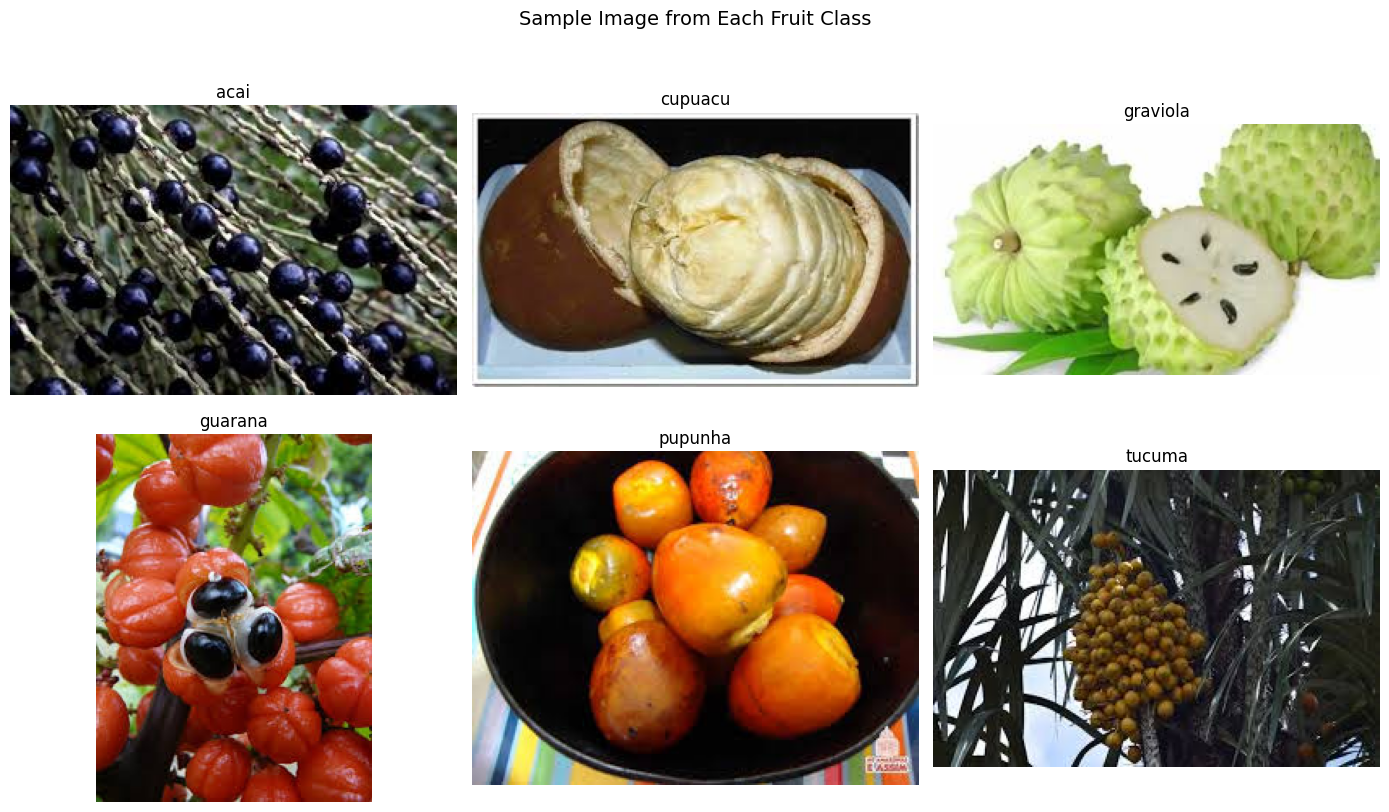

In [7]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

# Set your dataset path here
train_dir = "/content/drive/MyDrive/Ai ML/FruitinAmazon/train"   # update if needed
test_dir  = "/content/drive/MyDrive/Ai ML/FruitinAmazon/test"    # update if needed

# ── 1.1  Visualize one random image per class ──────────────────────────────
class_dirs = sorted([d for d in os.listdir(train_dir)
                     if os.path.isdir(os.path.join(train_dir, d))])

print(f"Classes found ({len(class_dirs)}): {class_dirs}")

num_classes = len(class_dirs)
cols = 3
rows = (num_classes + cols - 1) // cols   # auto rows so all classes fit

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path  = os.path.join(train_dir, cls)
    all_imgs  = [f for f in os.listdir(cls_path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    img_path  = os.path.join(cls_path, random.choice(all_imgs))
    img       = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis("off")

# hide unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Image from Each Fruit Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**What did I observe?**

Each subdirectory holds images of a single fruit type. The images vary quite a bit in terms of background, lighting and zoom level — some are close-up shots while others show the fruit in a natural setting. Image sizes also differ across classes. This tells me normalization and resizing to a fixed dimension will be important before feeding them into the model. The fruit types themselves look visually distinct (e.g. acai berries vs graviola), so the model should be able to pick up on those differences once it is properly trained.

In [8]:
# ── 1.2  Check and remove corrupted images ─────────────────────────────────
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()          # verify it is a real image
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No corrupted images found.")
else:
    print(f"\nTotal removed: {len(corrupted)}")

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data

In [19]:
import tensorflow as tf
import numpy as np

img_height      = 128
img_width       = 128
batch_size      = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (img_height, img_width),
    interpolation   = 'nearest',
    batch_size      = batch_size,
    shuffle         = True,
    validation_split= validation_split,
    subset          = 'training',
    seed            = 123
)
# Class names inferred from folder structure (before mapping)
class_names = train_ds_raw.class_names

train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels          = 'inferred',
    label_mode      = 'int',
    image_size      = (img_height, img_width),
    interpolation   = 'nearest',
    batch_size      = batch_size,
    shuffle         = False,
    validation_split= validation_split,
    subset          = 'validation',
    seed            = 123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split needed)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)
print("Class names :", class_names)
print("Num classes :", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


---
## Task 3: Build the CNN Model

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # ── Convolutional Block 1 ──────────────────────────────────────────────
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # ── Convolutional Block 2 ──────────────────────────────────────────────
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # ── Fully Connected Section ────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [11]:
# ── Compile ────────────────────────────────────────────────────────────────
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model automatically
checkpoint_cb = ModelCheckpoint(
    filepath         = 'best_fruit_cnn.h5',
    monitor          = 'val_accuracy',
    save_best_only   = True,
    verbose          = 1
)

# Stop early if val_loss stops improving for 15 epochs
earlystop_cb = EarlyStopping(
    monitor   = 'val_loss',
    patience  = 15,
    verbose   = 1,
    restore_best_weights = True
)

# ── Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs          = 250,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.1811 - loss: 2.1509
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn.h5



Epoch 1: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 930ms/step - accuracy: 0.1528 - loss: 2.3693 - val_accuracy: 0.0000e+00 - val_loss: 2.2495
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.2245 - loss: 1.9595
Epoch 2: val_accuracy improved from 0.00000 to 0.33333, saving model to best_fruit_cnn.h5



Epoch 2: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 959ms/step - accuracy: 0.2361 - loss: 1.9299 - val_accuracy: 0.3333 - val_loss: 1.6138
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.3791 - loss: 1.6472
Epoch 3: val_accuracy did not improve from 0.33333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 472ms/step - accuracy: 0.4028 - loss: 1.6208 - val_accuracy: 0.0556 - val_loss: 1.6773
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.2182 - loss: 1.5298
Epoch 4: val_accuracy improved from 0.33333 to 0.44444, saving model to best_fruit_cnn.h5



Epoch 4: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 0.2639 - loss: 1.4978 - val_accuracy: 0.4444 - val_loss: 1.4955
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5347 - loss: 1.2480
Epoch 5: val_accuracy improved from 0.44444 to 0.72222, saving model to best_fruit_cnn.h5



Epoch 5: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.5417 - loss: 1.2457 - val_accuracy: 0.7222 - val_loss: 1.0323
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7361 - loss: 0.9638
Epoch 6: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 546ms/step - accuracy: 0.7083 - loss: 0.9485 - val_accuracy: 0.7222 - val_loss: 1.0342
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8362 - loss: 0.7140
Epoch 7: val_accuracy improved from 0.72222 to 0.88889, saving model to best_fruit_cnn.h5



Epoch 7: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 853ms/step - accuracy: 0.8056 - loss: 0.7387 - val_accuracy: 0.8889 - val_loss: 0.6663
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9062 - loss: 0.5112
Epoch 8: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 682ms/step - accuracy: 0.8750 - loss: 0.5289 - val_accuracy: 0.8889 - val_loss: 0.5058
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9363 - loss: 0.3412
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step - accuracy: 0.9028 - loss: 0.4112 - val_accuracy: 0.8333 - val_loss: 0.5733
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9902 - loss: 0.2182
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.9861 - loss: 0.2229 - val_accuracy: 0.6111 - val_loss: 0.7947
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8999 - loss


Epoch 17: finished saving model to best_fruit_cnn.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 591ms/step - accuracy: 0.9861 - loss: 0.0336 - val_accuracy: 0.9444 - val_loss: 0.1755
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - loss: 0.0304
Epoch 18: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 0.0254 - val_accuracy: 0.9444 - val_loss: 0.2182
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 1.0000 - loss: 0.0090
Epoch 19: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 546ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 0.8333 - val_loss: 0.3014
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 1.0000 - loss: 0.0187
Epoch 20: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 721ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 0.8333 - val_loss: 0.3691
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 1.0000 -

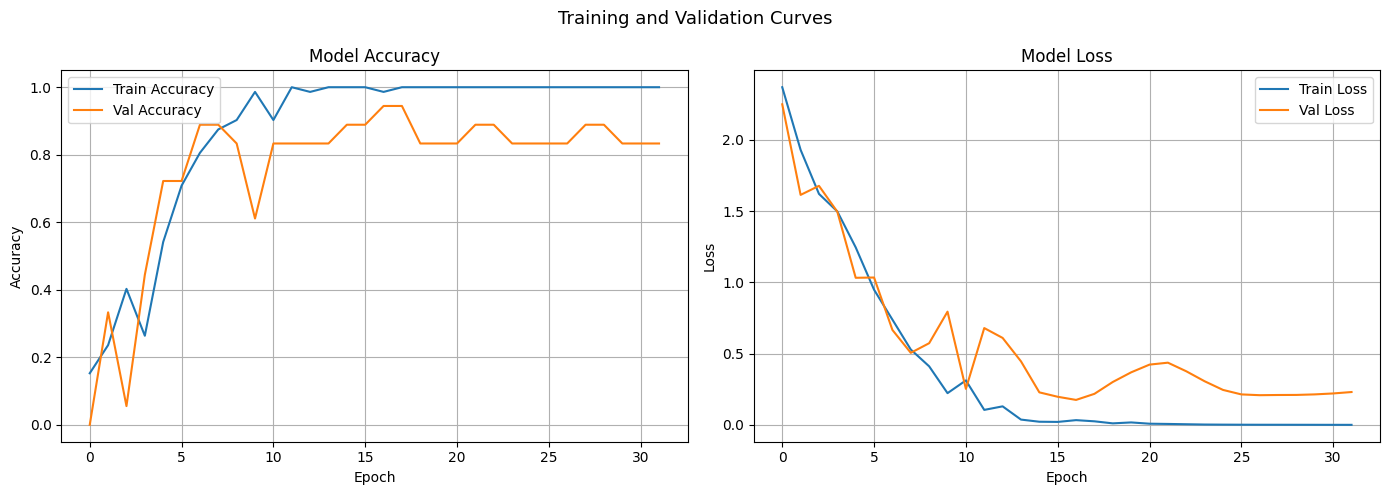

In [13]:
# ── Plot Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training and Validation Curves', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 5: Evaluate on Test Set

In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6000 - loss: 1.1452
Test Loss     : 1.1452
Test Accuracy : 0.6000 (60.00%)


---
## Task 6: Save and Reload the Model

In [15]:
# ── Save ───────────────────────────────────────────────────────────────────
model.save('fruit_cnn_final.h5')
print("Model saved as fruit_cnn_final.h5")

# ── Reload and re-evaluate ─────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model('fruit_cnn_final.h5')
print("Model loaded successfully.")

loss_reloaded, acc_reloaded = loaded_model.evaluate(test_ds)
print(f"Reloaded Model — Test Accuracy: {acc_reloaded:.4f}")

Model saved as fruit_cnn_final.h5
Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step - accuracy: 0.6000 - loss: 1.1452
Reloaded Model — Test Accuracy: 0.6000


---
## Task 7: Predictions and Classification Report

In [20]:
from sklearn.metrics import classification_report

# Collect all true labels and predictions from the test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds  = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

        acai       0.36      0.80      0.50         5
     cupuacu       0.57      0.80      0.67         5
    graviola       1.00      0.20      0.33         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.60        30
   macro avg       0.74      0.60      0.58        30
weighted avg       0.74      0.60      0.58        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


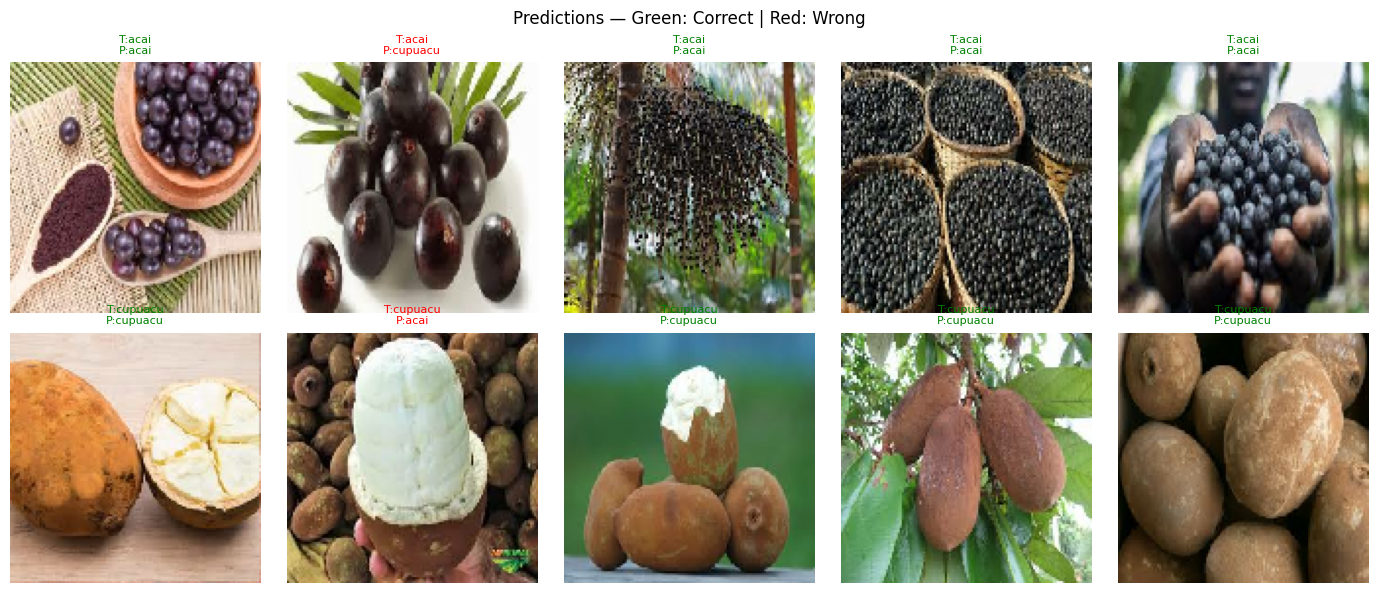

In [21]:
# ── Visualize a few predictions ────────────────────────────────────────────
sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    true_lbl = class_names[sample_labels[i]]
    pred_lbl = class_names[sample_preds[i]]
    color    = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=8, color=color)
    ax.axis('off')

plt.suptitle("Predictions — Green: Correct | Red: Wrong", fontsize=12)
plt.tight_layout()
plt.show()